In [ ]:
import json
import random
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_from_disk

ROOT = Path('.')
RESULTS_ROOT = ROOT / 'output' / 'results'
HF_ROOT = ROOT / 'data' / 'hf_dataset'


def _find_dataset_for_item(item_id: str):
    """Find (dataset_key, {model_name: result_dir}) for an item_id.

    Scans output/results/<model>/<dataset>/<freq>/<split>/config.json and
    picks the first (dataset, freq, split) whose item_ids contain item_id,
    then collects every model that has predictions for that same key.
    """
    found_key = None
    models = {}
    for model_dir in sorted(RESULTS_ROOT.iterdir()):
        if not model_dir.is_dir():
            continue
        for cfg_path in model_dir.rglob('config.json'):
            try:
                with open(cfg_path) as f:
                    cfg = json.load(f)
            except Exception:
                continue
            if item_id not in cfg.get('item_ids', []):
                continue
            key = cfg['dataset_config']
            if found_key is None:
                found_key = key
            if key != found_key:
                continue
            models[model_dir.name] = cfg_path.parent
            break
    if found_key is None:
        raise ValueError(f"item_id '{item_id}' not found in any results config.json")
    return found_key, models


def _load_actual_series(dataset_key: str, item_id: str):
    """Load the full ground-truth pandas Series for item_id.

    dataset_key is like 'CPCB/H/short'; HF dataset lives at HF_ROOT/CPCB/H.
    """
    dataset, freq_name, _split = dataset_key.split('/')
    ds = load_from_disk(str(HF_ROOT / dataset / freq_name))
    item_ids = ds['item_id']
    series_idx = item_ids.index(item_id)
    item = ds[series_idx]
    target = np.asarray(item['target'])
    if target.ndim == 2:
        target = target[0]
    start_raw = item['start']
    start = pd.Timestamp(start_raw.item() if hasattr(start_raw, 'item') else start_raw)
    offset = pd.tseries.frequencies.to_offset(item['freq'])
    index = pd.date_range(start, periods=len(target), freq=offset)
    return pd.Series(target, index=index), series_idx


def plot_random_windows(item_id: str, n: int = 4, context_steps: int = 72,
                        seed=None, models=None, show_interval: bool = True):
    """Plot n random forecast windows for item_id, overlaying every model.

    Parameters
    ----------
    item_id : e.g. 'site_105_North_Campus_DU_Delhi_IMD_PM2.5'
    n : number of random windows to draw
    context_steps : history points to show before each forecast
    seed : RNG seed for reproducibility
    models : restrict to this subset of model names (default: all available)
    show_interval : shade 10th-90th percentile band for each model
    """
    dataset_key, model_dirs = _find_dataset_for_item(item_id)
    if models is not None:
        model_dirs = {m: model_dirs[m] for m in models if m in model_dirs}
        if not model_dirs:
            raise ValueError('None of the requested models have this item_id')
    print(f'dataset: {dataset_key}   models: {list(model_dirs)}')

    series, series_idx = _load_actual_series(dataset_key, item_id)

    loaded = {}
    num_windows = None
    for model_name, path in model_dirs.items():
        npz = np.load(path / 'predictions.npz')
        with open(path / 'config.json') as f:
            cfg = json.load(f)
        ql = np.asarray(cfg['quantile_levels'])
        preds = npz['predictions_quantiles'].astype(np.float32) * cfg['prediction_scale_factor']
        loaded[model_name] = {
            'preds': preds[series_idx],              # (W, Q, V, H)
            'ts':    npz['timestamps'][series_idx],  # (W, H)
            'q10':   int(np.argmin(np.abs(ql - 0.1))),
            'q50':   int(np.argmin(np.abs(ql - 0.5))),
            'q90':   int(np.argmin(np.abs(ql - 0.9))),
        }
        n_windows = preds.shape[1]
        num_windows = n_windows if num_windows is None else min(num_windows, n_windows)

    rng = random.Random(seed)
    window_idxs = sorted(rng.sample(range(num_windows), k=min(n, num_windows)))

    cmap = plt.get_cmap('tab10')
    model_colors = {m: cmap(i % 10) for i, m in enumerate(loaded)}

    fig, axes = plt.subplots(len(window_idxs), 1,
                             figsize=(14, 3.2 * len(window_idxs)),
                             squeeze=False)
    for ax, win_idx in zip(axes[:, 0], window_idxs):
        first = next(iter(loaded.values()))
        timestamps = pd.to_datetime(first['ts'][win_idx], unit='s')
        forecast_start = timestamps[0]
        step = timestamps[1] - timestamps[0]
        context_start = forecast_start - context_steps * step
        actual_ctx = series.loc[context_start:timestamps[-1]]
        actual_fc = series.reindex(timestamps)

        ax.plot(actual_ctx.index, actual_ctx.values, color='black', lw=1.5, label='Actual')
        ax.scatter(actual_fc.index, actual_fc.values, color='black', s=14, zorder=5)

        for m, d in loaded.items():
            c = model_colors[m]
            median = d['preds'][win_idx, d['q50'], 0, :]
            ax.plot(timestamps, median, color=c, lw=1.3, label=m)
            if show_interval:
                lo = d['preds'][win_idx, d['q10'], 0, :]
                hi = d['preds'][win_idx, d['q90'], 0, :]
                ax.fill_between(timestamps, lo, hi, color=c, alpha=0.10)

        ax.axvline(forecast_start, color='gray', linestyle=':', alpha=0.7)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
        ax.set_title(f'{item_id}  |  window {win_idx}')
        ax.set_ylabel('value')
        ax.tick_params(axis='x', rotation=25)

    axes[0, 0].legend(loc='upper left', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


dataset: CPCB/H/short   models: ['TimesFM-2.5', 'visiontspp_base', 'patchtst', 'seasonal_naive']


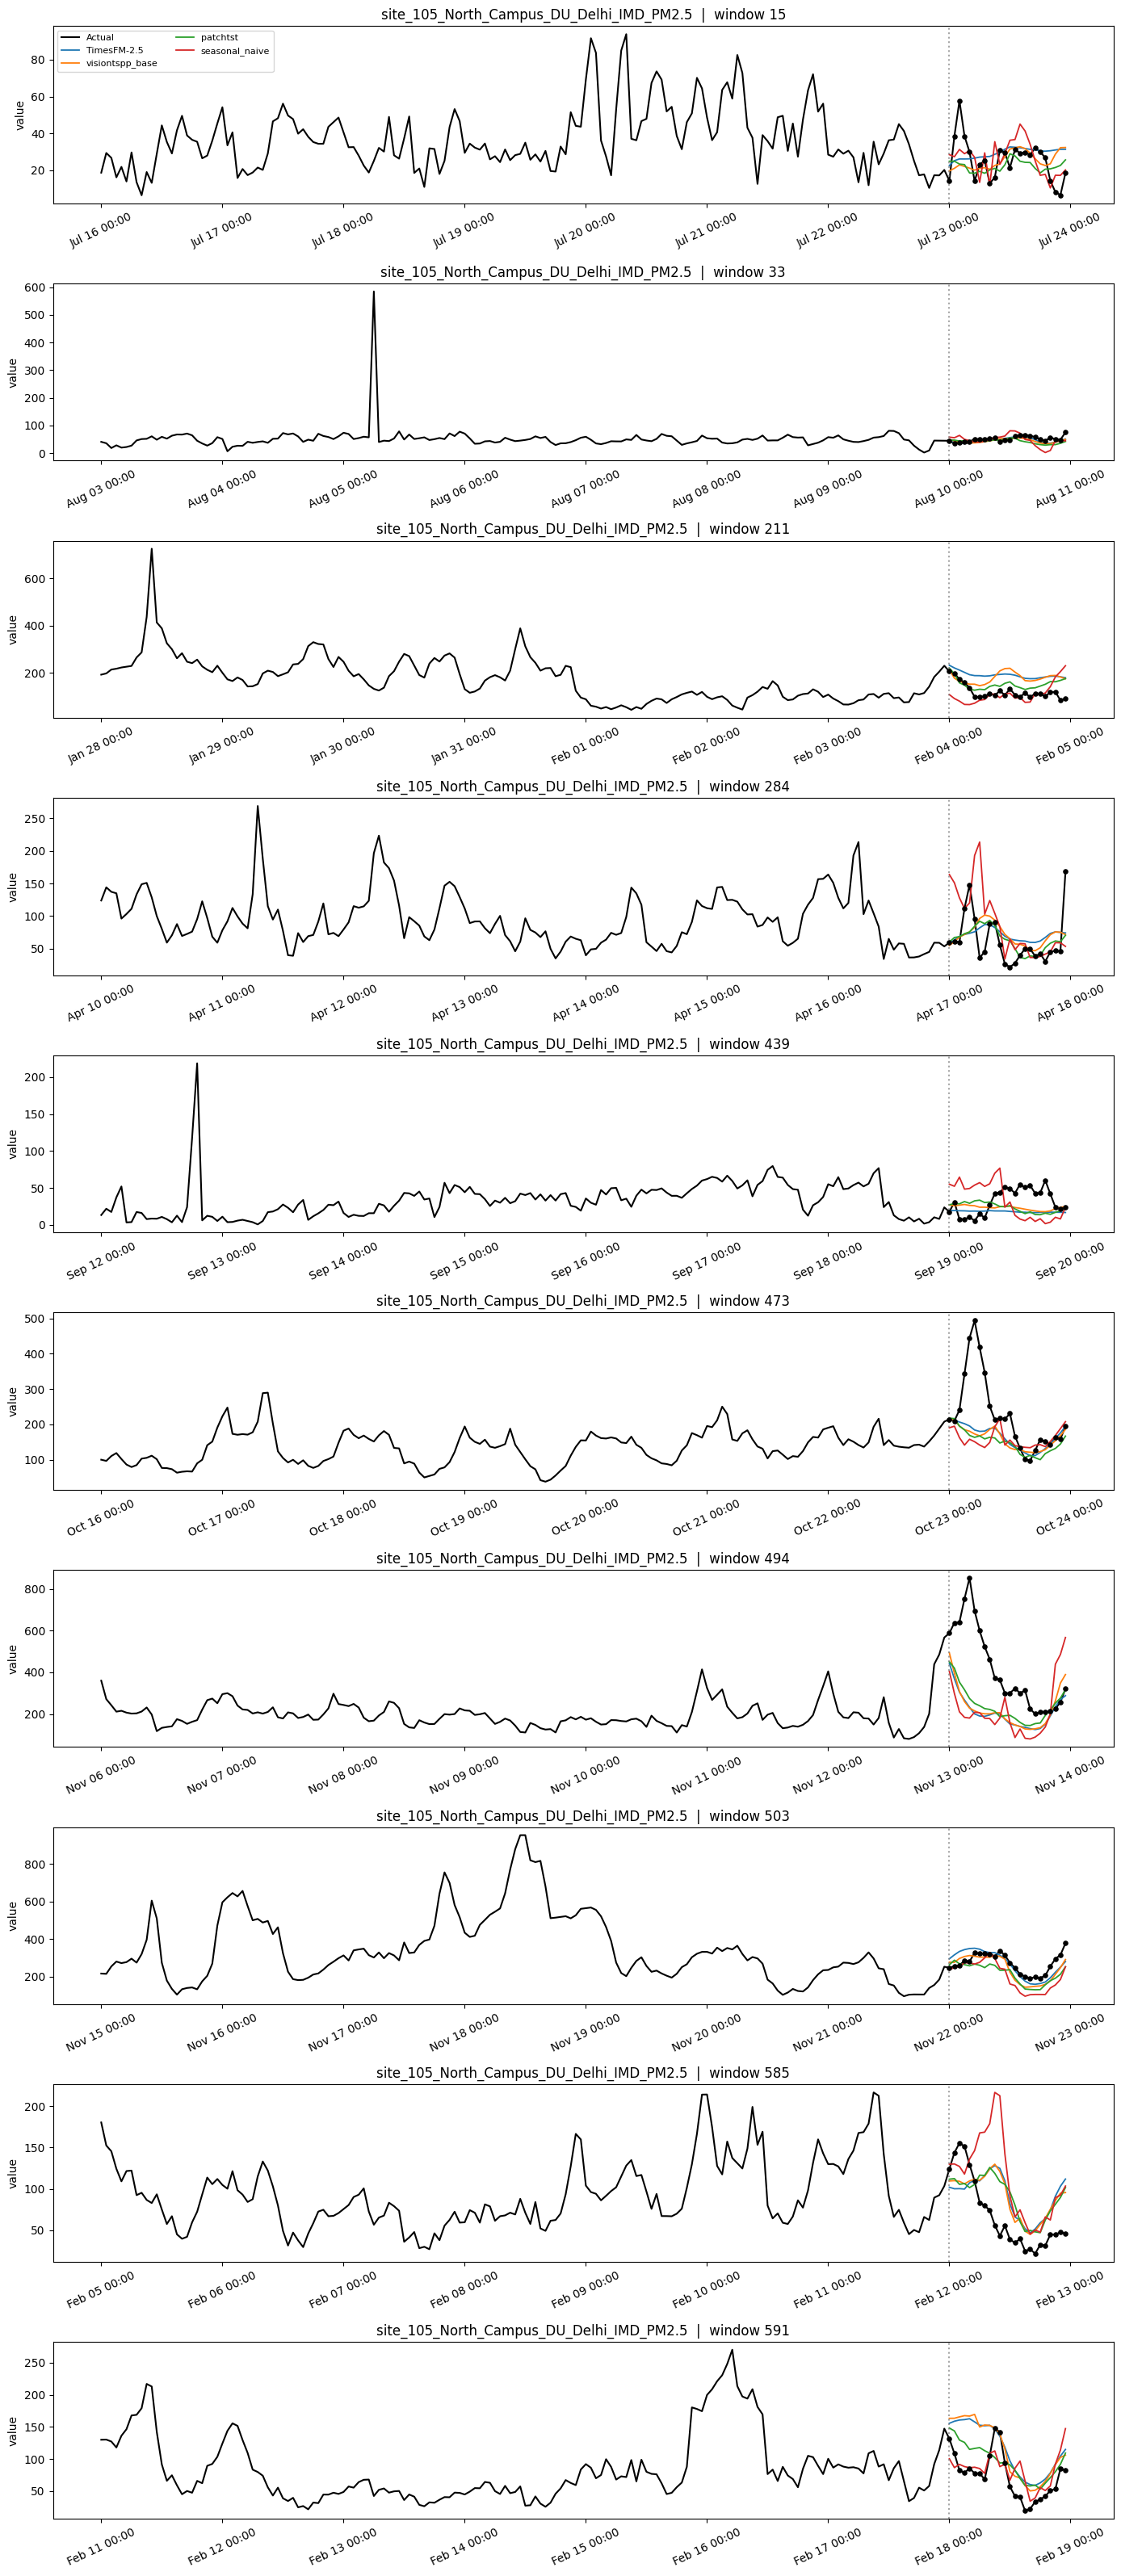

In [15]:
plot_random_windows(
    item_id='site_105_North_Campus_DU_Delhi_IMD_PM2.5',
    n=10,
    context_steps=168,
    seed=10,
    models=["TimesFM-2.5", "visiontspp_base", "patchtst", "seasonal_naive"],
    show_interval=False
)
